# Titanic Survival Prediction

In this notebook, we build a machine learning model to predict whether a passenger survived the Titanic disaster.

This notebook helps revise:
- binary classification
- missing value handling
- categorical encoding
- preprocessing pipelines
- model training and evaluation

We will use:
- Logistic Regression as a baseline model
- Random Forest as a stronger tree-based model

## 2. Import libraries

We import:
- pandas and numpy for data handling
- matplotlib and seaborn for visualization
- scikit-learn tools for preprocessing, pipelines, modeling, and evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set(style="whitegrid")

## 3. Load the dataset

Download `train.csv` from the Kaggle Titanic competition and place it in your notebook folder.

The Kaggle Titanic training dataset includes columns such as:
- Survived
- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

The target column is:
- `Survived` → 0 = did not survive, 1 = survived

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Basic inspection

We check:
- shape of the dataset
- column names
- missing values
- basic statistics

In [6]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())

Shape: (891, 12)

Columns:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## 2. Quick EDA

We look at:
- survival distribution
- survival by sex
- survival by passenger class

/tmp/ipykernel_3288/2873709891.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data=df, palette="Set2")


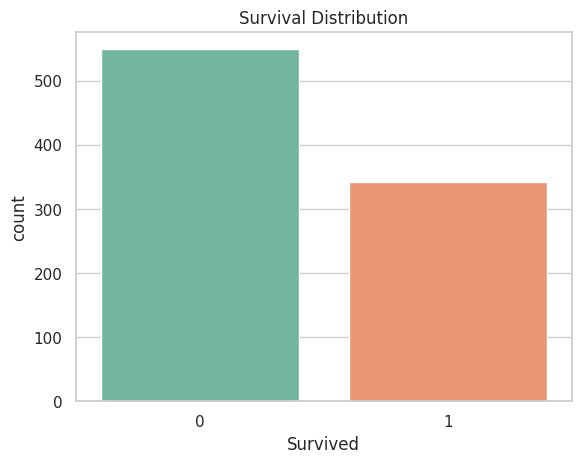

In [8]:
sns.countplot(x="Survived", data=df, palette="Set2")
plt.title("Survival Distribution")
plt.show()

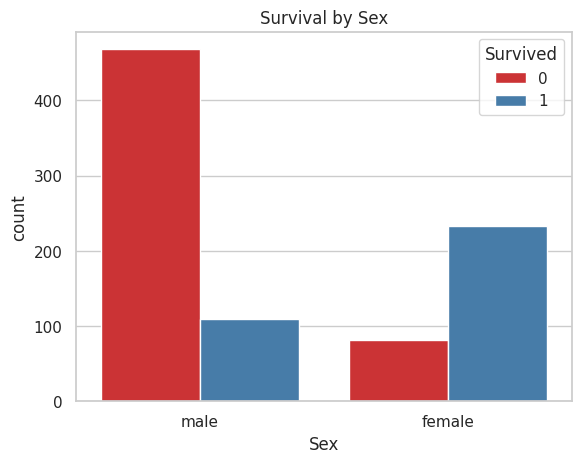

In [9]:
sns.countplot(x="Sex", hue="Survived", data=df, palette="Set1")
plt.title("Survival by Sex")
plt.show()

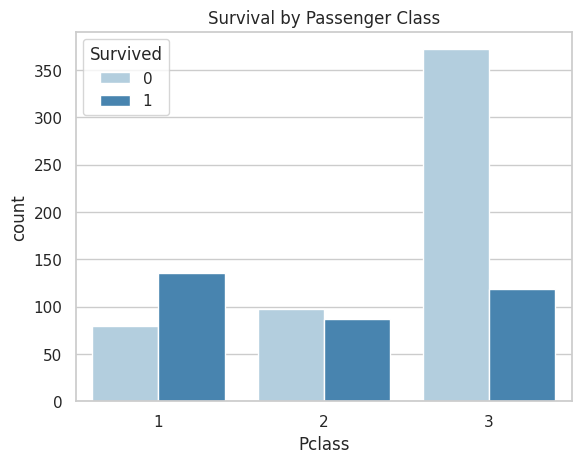

In [10]:
sns.countplot(x="Pclass", hue="Survived", data=df, palette="Blues")
plt.title("Survival by Passenger Class")
plt.show()

## 3. Select features and target

We choose a small, useful subset of columns:

Features:
- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

Target:
- Survived

This is similar to common Titanic ML tutorials.

In [11]:
selected_features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

X = df[selected_features].copy()
y = df["Survived"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 7)
y shape: (891,)


## 4. Identify numeric and categorical columns

We define:
- numeric features → imputation + scaling
- categorical features → imputation + one-hot encoding

In [12]:
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'SibSp', 'Parch', 'Fare']
Categorical features: ['Pclass', 'Sex', 'Embarked']


## 5. Build preprocessing pipelines

For numeric columns:
- impute missing values with **median**
- scale with **StandardScaler**

For categorical columns:
- impute missing values with **most frequent** value
- encode using **OneHotEncoder**

We combine both in a `ColumnTransformer`.

In [13]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 6. Train-test split

We split the data into:
- 80% training set
- 20% test set

We stratify by `Survived` to maintain the survival ratio in both sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (712, 7)
X_test : (179, 7)


## 7. Baseline model: Logistic Regression

We create a pipeline:

1. Apply preprocessing (`ColumnTransformer`)
2. Fit a `LogisticRegression` model

This is a standard baseline for binary classification.

In [15]:
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)

## 8. Evaluate Logistic Regression

We use:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Full classification report

Logistic Regression performance:
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1-score : 0.7244

Classification report:

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



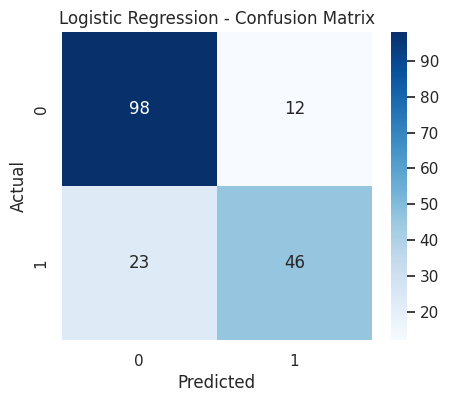

In [16]:
def evaluate_binary(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"{model_name} performance:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification report:\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

evaluate_binary(y_test, y_pred_logreg, model_name="Logistic Regression")

## 9. Stronger model: Random Forest

We now try a `RandomForestClassifier` within the same preprocessing pipeline.

Tree-based models can capture non-linear relationships and interactions between features.

In [17]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

## 10. Evaluate Random Forest

Random Forest performance:
Accuracy : 0.8156
Precision: 0.8103
Recall   : 0.6812
F1-score : 0.7402

Classification report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



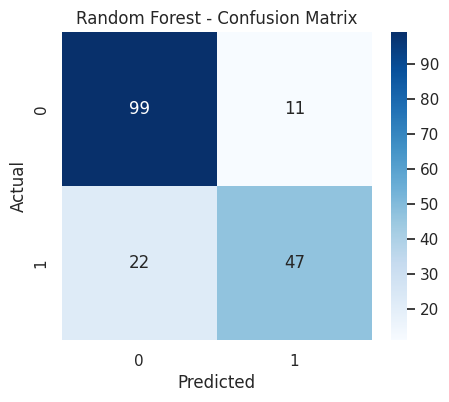

In [18]:
evaluate_binary(y_test, y_pred_rf, model_name="Random Forest")

## 11. Compare model performance

We create a small table to compare Logistic Regression and Random Forest on key metrics.

In [19]:
def get_scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

scores_logreg = get_scores(y_test, y_pred_logreg)
scores_rf = get_scores(y_test, y_pred_rf)

results = pd.DataFrame([scores_logreg, scores_rf],
                       index=["Logistic Regression", "Random Forest"])
results

,Accuracy,Precision,Recall,F1
Logistic Regression,0.804469,0.793103,0.666667,0.724409
Random Forest,0.815642,0.810345,0.681159,0.740157


## 12. Predict survival for a sample passenger

We take one passenger from the test set and predict survival with the Random Forest model.

In [20]:
sample = X_test.iloc[[0]]
sample_prediction = rf_pipeline.predict(sample)[0]

print("Passenger features:\n")
display(sample)

print("Actual Survived   :", y_test.iloc[0])
print("Predicted Survived:", sample_prediction)

Passenger features:



,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
565,3,male,24.0,2,0,24.15,S


Actual Survived   : 0
Predicted Survived: 0


## 13. Summary

In this notebook, we:

- Loaded a Titanic CSV directly from a GitHub URL
- Explored dataset structure and survival patterns
- Selected a subset of informative features
- Handled missing values and categorical variables with `ColumnTransformer`
- Built two models:
  - Logistic Regression (baseline)
  - Random Forest (stronger tree-based model)
- Evaluated accuracy, precision, recall, F1, and confusion matrices
- Compared models and made predictions on individual passengers

This gives you a complete end-to-end binary classification workflow on a realistic tabular dataset.